# Anatomia del `TransactionEncoder`

Notebook per visualizzare e capire **come ogni feature viene trasformata in embedding**
prima di entrare nel `FieldTransformer`.

Pipeline: `batch dict di tensori (B, T)` → `TransactionEncoder` → `(B, T, n_fields, d_field)`.

Ogni feature dello schema (`DEFAULT_FEATURES`) possiede il proprio `build()` (sotto-moduli)
ed `encode()` (tensori di campo). Qui le apriamo una per una:

| feature | tipo | slot |
|---|---|---|
| `importo` | `NumericFeature(signed=True)` | 2 — valore (banco sin/cos) + segno |
| `merchant` | `HighCardCategoricalFeature` | 1 — doppio hashing su 2 tabelle sommate |
| `cocau` | `CategoricalFeature(501)` | 1 — embedding classico |
| `timestamp` | `DatetimeFeature` | 4 — hour / dow / dom / month |

> **Nota**: senza un checkpoint addestrato i pesi sono casuali — quello che si vede è la
> **struttura geometrica del meccanismo** (continuità, periodicità, collisioni hash, token
> [MASK]), non la semantica appresa. Imposta `CKPT_PATH` più sotto per usare pesi veri.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "config.toml").exists():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.decomposition import PCA

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_columns", 60)
torch.manual_seed(0)

from src.models.hier_transformer.encoder import TransactionEncoder
from src.models.hier_transformer.features import (
    DEFAULT_FEATURES,
    HighCardCategoricalFeature,
    _decompose_unix_timestamp,
    mtm_mask_key,
)
from src.models.hier_transformer.model import EmbeddingModel

## Setup: dati reali + modello

Fittiamo i normalizer sulle transazioni sintetiche (come fa `DataModule`) e costruiamo il
modello. Se hai un checkpoint (`model_artifacts/<dataset>/latest/model_final.pt`), puntalo
con `CKPT_PATH` per vedere gli embedding **appresi**.

In [2]:
df = pd.read_csv(REPO_ROOT / "data/transactions_simple_delta_train.csv")
features = TransactionEncoder.fit_features(DEFAULT_FEATURES, df)

CKPT_PATH = None  # es. REPO_ROOT / "model_artifacts/simple_delta/latest/model_final.pt"
if CKPT_PATH is not None:
    model = EmbeddingModel.load(CKPT_PATH, features=features, map_location="cpu")
    print(f"Checkpoint caricato: {CKPT_PATH}")
else:
    model = EmbeddingModel(features, use_gradient_checkpointing=False)
    print("Nessun checkpoint: pesi a inizializzazione casuale")
model.eval()

encoder = model.backbone.encoder
D_FIELD = 64
SLOT_LABELS = [
    "importo (valore)", "importo (segno)", "merchant", "cocau",
    "ts: hour", "ts: dow", "ts: dom", "ts: month",
]
schema = pd.DataFrame(
    [
        {"feature": f.name, "tipo": type(f).__name__, "n_slots": f.n_slots}
        for f in features
    ],
)
print(f"n_fields totali: {encoder.n_fields}")
schema

Nessun checkpoint: pesi a inizializzazione casuale
n_fields totali: 8


/home/julien/Documents/python-proj/embeddingclient/src/models/hier_transformer/field_transformer.py:55: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


,feature,tipo,n_slots
0,importo,NumericFeature,2
1,merchant,HighCardCategoricalFeature,1
2,cocau,CategoricalFeature,1
3,timestamp,DatetimeFeature,4


## 1. `NumericFeature("importo")` — normalizzazione

Prima dell'encoder, il `NumericNormalizer` applica **clip al 99° percentile → log1p →
z-score** (fittato sui valori non-zero del train). Lo zero resta zero (è il padding).
L'encoder quindi non vede mai euro grezzi ma valori ~N(0,1).

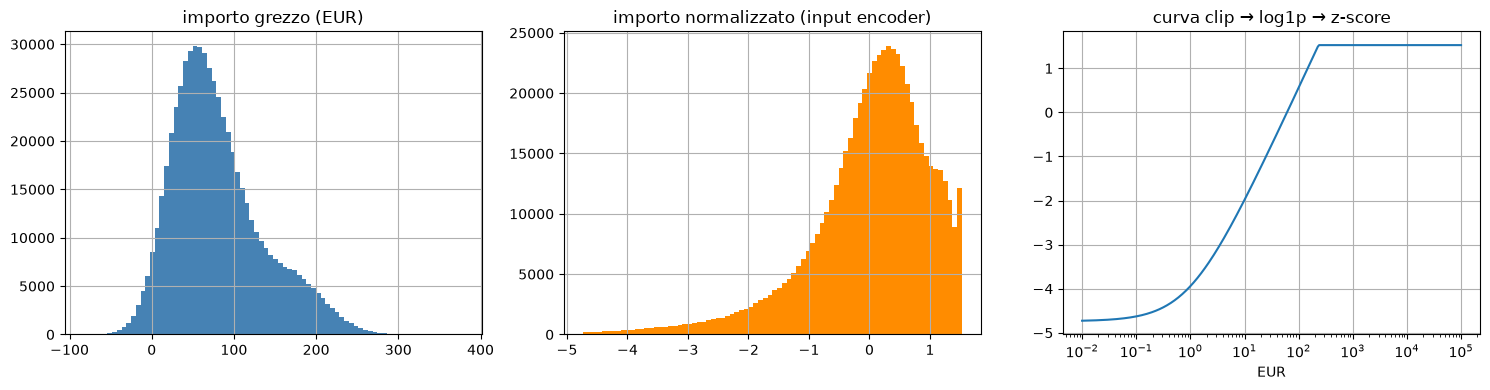

In [3]:
normalizer = features[0].normalizer
raw = df["importo"].to_numpy(dtype=np.float32)
normed = normalizer(torch.tensor(raw)).numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(raw, bins=80, color="steelblue")
axes[0].set_title("importo grezzo (EUR)")
axes[1].hist(normed, bins=80, color="darkorange")
axes[1].set_title("importo normalizzato (input encoder)")

sweep_eur = np.logspace(-2, 5, 300, dtype=np.float32)
axes[2].semilogx(sweep_eur, normalizer(torch.tensor(sweep_eur)).numpy())
axes[2].set_title("curva clip → log1p → z-score")
axes[2].set_xlabel("EUR")
plt.tight_layout()
plt.show()

## 2. `NumericEncoder` — banco di frequenze sin/cos

Il valore normalizzato $x$ viene moltiplicato per 16 frequenze apprese
(`logspace(0, 3)` all'init), passato per sin/cos e proiettato linearmente a `d_field=64`.
È l'analogo continuo di un positional encoding: valori **vicini producono embedding
vicini** (continuità), e le frequenze alte aggiungono dettaglio fine.

- *Heatmap*: ogni colonna è l'embedding di un valore del sweep — le bande mostrano i canali
  sin/cos alle diverse frequenze.
- *Similarità coseno*: la diagonale larga = continuità; le oscillazioni fuori diagonale
  vengono dai canali ad alta frequenza.

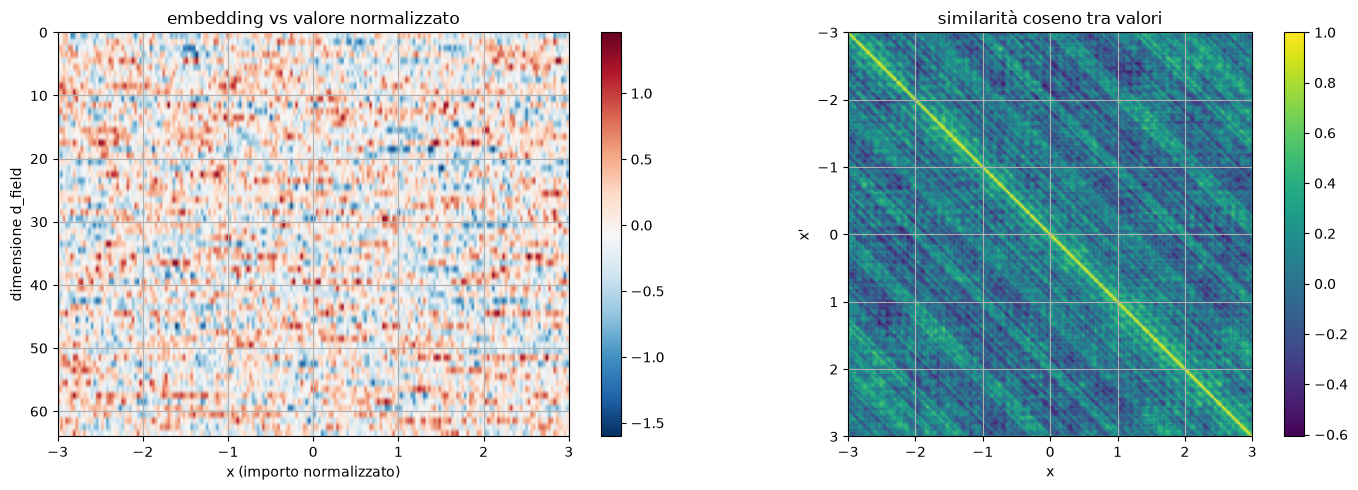

16 frequenze apprese: min=1.00, max=1000.00


In [4]:
value_encoder = encoder.encoders[0]["value"]
sweep = torch.linspace(-3, 3, 200)
with torch.no_grad():
    emb_sweep = value_encoder(sweep.unsqueeze(0)).squeeze(0)  # (200, 64)

emb_n = torch.nn.functional.normalize(emb_sweep, dim=-1)
cos_sim = emb_n @ emb_n.T

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
im0 = axes[0].imshow(emb_sweep.T, aspect="auto", cmap="RdBu_r",
                     extent=[-3, 3, D_FIELD, 0])
axes[0].set_title("embedding vs valore normalizzato")
axes[0].set_xlabel("x (importo normalizzato)")
axes[0].set_ylabel("dimensione d_field")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(cos_sim, cmap="viridis", extent=[-3, 3, 3, -3])
axes[1].set_title("similarità coseno tra valori")
axes[1].set_xlabel("x")
axes[1].set_ylabel("x'")
plt.colorbar(im1, ax=axes[1])
plt.tight_layout()
plt.show()

freqs = value_encoder.frequencies.detach()
print(f"16 frequenze apprese: min={freqs.min():.2f}, max={freqs.max():.2f}")

## 3. Segno e token [MASK]

`signed=True` aggiunge un secondo slot: `nn.Embedding(4)` con **0=pad, 1=positivo,
2=negativo, 3=[MASK]**. Il `NumericEncoder` ha inoltre un vettore `mask_token` appreso che
sostituisce l'output nelle posizioni mascherate dall'MTM — così una posizione mascherata è
**distinguibile** sia dal padding sia da un genuino valore zero.

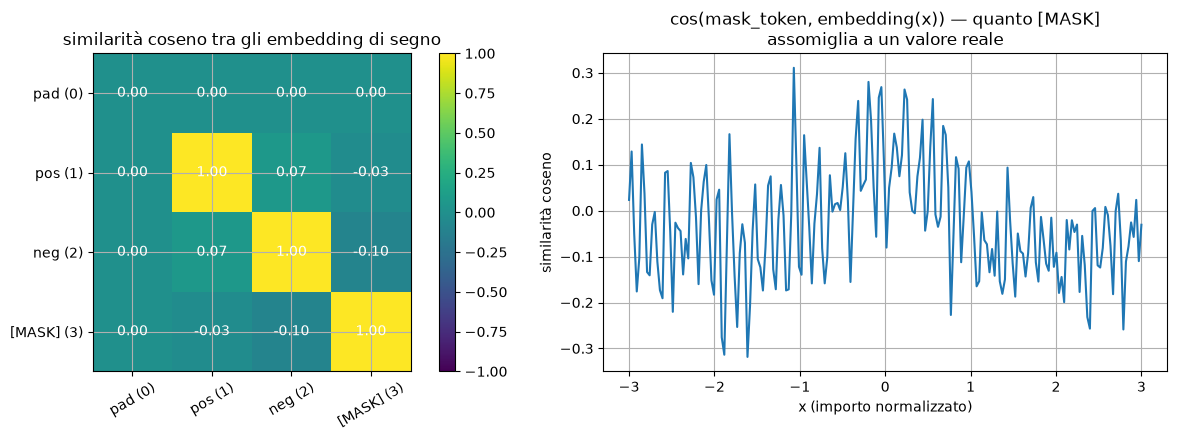

In [5]:
sign_weight = encoder.encoders[0]["sign"].weight.detach()
labels = ["pad (0)", "pos (1)", "neg (2)", "[MASK] (3)"]
sign_n = torch.nn.functional.normalize(sign_weight, dim=-1)
sim = (sign_n @ sign_n.T).numpy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
im = axes[0].imshow(sim, cmap="viridis", vmin=-1, vmax=1)
axes[0].set_xticks(range(4), labels, rotation=30)
axes[0].set_yticks(range(4), labels)
axes[0].set_title("similarità coseno tra gli embedding di segno")
for i in range(4):
    for j in range(4):
        axes[0].text(j, i, f"{sim[i, j]:.2f}", ha="center", va="center", color="w")
plt.colorbar(im, ax=axes[0])

mask_token = value_encoder.mask_token.detach()
mask_n = torch.nn.functional.normalize(mask_token, dim=0)
axes[1].plot(sweep, (emb_n @ mask_n).numpy())
axes[1].set_title("cos(mask_token, embedding(x)) — quanto [MASK]\nassomiglia a un valore reale")
axes[1].set_xlabel("x (importo normalizzato)")
axes[1].set_ylabel("similarità coseno")
plt.tight_layout()
plt.show()

## 4. `DatetimeFeature("timestamp")` — hour / dow / dom / month

Il timestamp Unix viene decomposto in **4 componenti di calendario** (aritmetica intera
Fliegel-Van Flandern, GPU-safe), ognuna con la propria tabella di embedding.
Prima una verifica della decomposizione su transazioni reali:

In [6]:
ts_demo = torch.tensor(df["timestamp"].head(8).to_numpy(np.int64))
hour, dow, dom, month = _decompose_unix_timestamp(ts_demo)
pd.DataFrame({
    "timestamp": ts_demo.numpy(),
    "datetime (UTC)": pd.to_datetime(ts_demo.numpy(), unit="s"),
    "hour [1..24]": hour.numpy(),
    "dow [1..7, lun=1]": dow.numpy(),
    "dom [1..31]": dom.numpy(),
    "month [1..12]": month.numpy(),
})

,timestamp,datetime (UTC),hour [1..24],"dow [1..7, lun=1]",dom [1..31],month [1..12]
0,1644034449,2022-02-05 04:14:09,5,6,5,2
1,1644119727,2022-02-06 03:55:27,4,7,6,2
2,1645184422,2022-02-18 11:40:22,12,5,18,2
3,1645220753,2022-02-18 21:45:53,22,5,18,2
4,1645903601,2022-02-26 19:26:41,20,6,26,2
5,1648297610,2022-03-26 12:26:50,13,6,26,3
6,1649132600,2022-04-05 04:23:20,5,2,5,4
7,1649580298,2022-04-10 08:44:58,9,7,10,4


Le matrici di similarità coseno tra gli indici di ogni tabella: **con un modello addestrato**
qui ci si aspetta struttura ciclica (ora 23 ≈ ora 0, domenica ≈ sabato per lo spending
pattern…); a init casuale sono ~ortogonali (diagonale e poco altro).

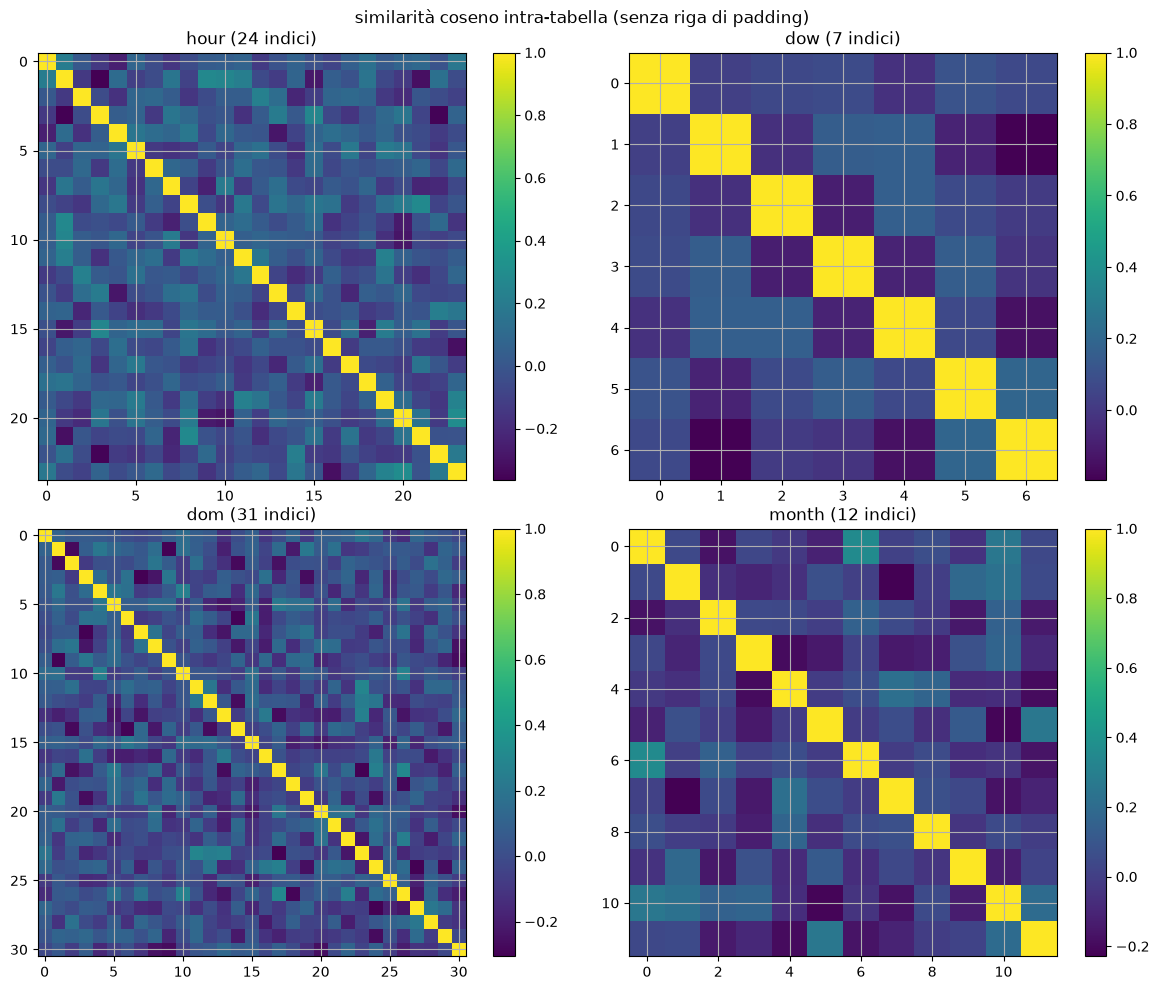

In [7]:
dt_tables = encoder.encoders[3]
dt_names = ["hour", "dow", "dom", "month"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, table, name in zip(axes.flat, dt_tables, dt_names):
    w = torch.nn.functional.normalize(table.weight.detach()[1:], dim=-1)  # senza pad
    im = ax.imshow((w @ w.T).numpy(), cmap="viridis")
    ax.set_title(f"{name} ({w.shape[0]} indici)")
    plt.colorbar(im, ax=ax)
plt.suptitle("similarità coseno intra-tabella (senza riga di padding)")
plt.tight_layout()
plt.show()

Proiezione PCA 2D delle 24 ore: con pesi addestrati le ore dovrebbero disporsi lungo una
traiettoria (quasi-)circolare che riflette la ciclicità giornaliera.

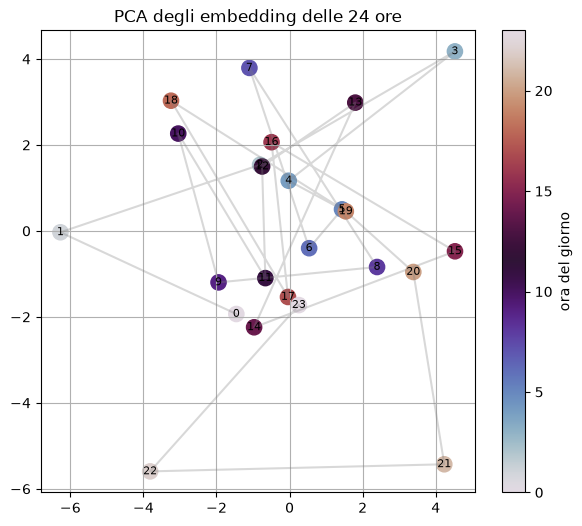

In [8]:
hour_w = dt_tables[0].weight.detach()[1:].numpy()  # (24, 64)
xy = PCA(n_components=2).fit_transform(hour_w)

plt.figure(figsize=(7, 6))
plt.plot(xy[:, 0], xy[:, 1], "-", alpha=0.3, color="gray")
plt.scatter(xy[:, 0], xy[:, 1], c=range(24), cmap="twilight", s=120)
for i, (x, y) in enumerate(xy):
    plt.annotate(str(i), (x, y), fontsize=8, ha="center", va="center")
plt.colorbar(label="ora del giorno")
plt.title("PCA degli embedding delle 24 ore")
plt.show()

## 5. `CategoricalFeature("cocau")` — tabella classica + riga [MASK]

`nn.Embedding(vocab_size + 1)`: indice 0 = padding (gradiente sempre nullo), ultima riga =
**[MASK]** per l'MTM (mai una classe predetta: le logit della testa MTM restano su
`[0, vocab_size)`).

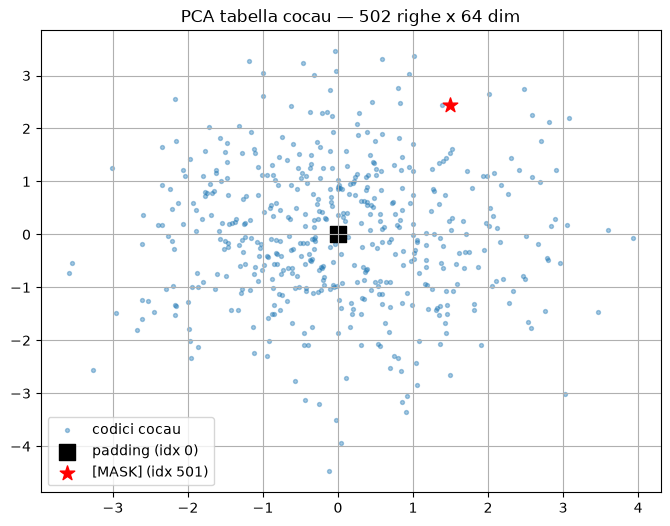

In [9]:
cocau_w = encoder.encoders[2].weight.detach().numpy()
xy = PCA(n_components=2).fit_transform(cocau_w)

plt.figure(figsize=(8, 6))
plt.scatter(xy[1:-1, 0], xy[1:-1, 1], s=8, alpha=0.4, label="codici cocau")
plt.scatter(*xy[0], color="black", s=120, marker="s", label="padding (idx 0)")
plt.scatter(*xy[-1], color="red", s=120, marker="*", label=f"[MASK] (idx {len(cocau_w) - 1})")
plt.legend()
plt.title(f"PCA tabella cocau — {cocau_w.shape[0]} righe x {cocau_w.shape[1]} dim")
plt.show()

## 6. `HighCardCategoricalFeature("merchant")` — doppio hashing

I merchant sono stringhe: `to_stable_id` (blake2b) li mappa a int64 stabili, poi **due hash
indipendenti** (costanti moltiplicative di Knuth) li portano in `[1, 5002]` su due tabelle
distinte, sommate. Con un solo hash due merchant che collidono sarebbero
*indistinguibili*; con due tabelle la collisione deve avvenire su **entrambi** gli hash —
probabilità ~1/5002².

In [10]:
merchants = sorted(df["merchant"].unique())
ids = torch.tensor([HighCardCategoricalFeature.to_stable_id(m) for m in merchants])
hash_a, hash_b = HighCardCategoricalFeature.to_hash_buckets(ids, 5003)

demo = pd.DataFrame({
    "merchant": merchants[:10],
    "stable_id (blake2b)": ids[:10].numpy(),
    "bucket A": hash_a[:10].numpy(),
    "bucket B": hash_b[:10].numpy(),
})

n = len(merchants)
coll_a = n - len(set(hash_a.tolist()))
coll_pair = n - len(set(zip(hash_a.tolist(), hash_b.tolist())))
print(f"{n} merchant distinti -> collisioni solo hash A: {coll_a}, "
      f"collisioni sulla coppia (A, B): {coll_pair}")
demo

26 merchant distinti -> collisioni solo hash A: 0, collisioni sulla coppia (A, B): 0


,merchant,stable_id (blake2b),bucket A,bucket B
0,Airbnb,1131892481924233149,4246,4394
1,Aldi,3596660553164100337,2310,2546
2,Amazon,966298441736924364,2875,1683
3,Apple,2723825846642413916,3885,4967
4,Bancomat,447024154062331787,1558,2744
5,Booking,6842597641390356139,2208,2272
6,Carrefour,6313881221060891642,2501,4001
7,Conad,7208817407677326108,77,2215
8,Coop,3660675101611245113,3106,1850
9,Decathlon,1887295902577668179,2918,1016


## 7. Forward completo su un batch reale

Costruiamo un batch con il vero `TrainTransactionDataset` e guardiamo il tensore dei campi
`(B, T, 8, 64)` prodotto dall'encoder: l'"impronta" di una singola transazione (8 slot ×
64 dim) e la norma di ogni slot lungo la sequenza (il padding deve avere norma ~0 sugli
slot con `padding_idx=0`).

batch keys: ['cocau', 'delta_t', 'importo', 'merchant', 'padding_mask', 'timestamp']
fields: (4, 16, 8, 64)  (B, T, n_fields, d_field)


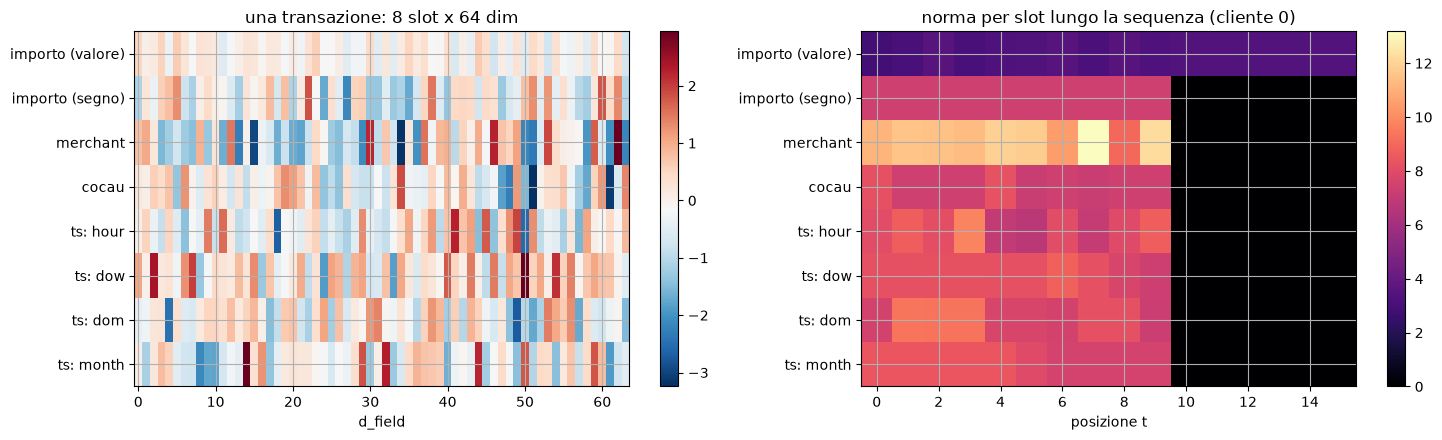

In [11]:
from src.models.hier_transformer.data import TrainTransactionDataset, collate_train

# primi 8 clienti; il cliente 0 viene troncato a 10 transazioni per avere
# anche posizioni di padding nel batch (seq_len=16)
demo_df = df[df["client_id"] < 8]
demo_df = pd.concat([
    demo_df[demo_df["client_id"] == 0].head(10),
    demo_df[demo_df["client_id"] != 0],
])
ds = TrainTransactionDataset(
    demo_df, client_col="client_id", timestamp_col="timestamp",
    features=features, seq_len=16, train_windows_per_client=1, seed=0,
)
batch, client_ids = collate_train([ds[i] for i in range(4)])
with torch.no_grad():
    fields = encoder(batch)  # (B, T, 8, 64)
print(f"batch keys: {sorted(batch)}")
print(f"fields: {tuple(fields.shape)}  (B, T, n_fields, d_field)")

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
im0 = axes[0].imshow(fields[0, 0].numpy(), aspect="auto", cmap="RdBu_r")
axes[0].set_yticks(range(8), SLOT_LABELS)
axes[0].set_title("una transazione: 8 slot x 64 dim")
axes[0].set_xlabel("d_field")
plt.colorbar(im0, ax=axes[0])

norms = fields.norm(dim=-1)[0].T  # (8, T)
im1 = axes[1].imshow(norms.numpy(), aspect="auto", cmap="magma")
axes[1].set_yticks(range(8), SLOT_LABELS)
axes[1].set_title("norma per slot lungo la sequenza (cliente 0)")
axes[1].set_xlabel("posizione t")
plt.colorbar(im1, ax=axes[1])
plt.tight_layout()
plt.show()

## 8. Effetto del masking MTM

`build_mtm_targets` azzera i valori mascherati **e** pubblica la maschera nel batch
(`<name>__mtm_mask`); `encode` la consuma sostituendo la rappresentazione [MASK].
Confrontiamo lo slot `cocau` di una stessa posizione in tre condizioni: originale,
mascherata, padding — mascherato ≠ padding è esattamente il punto del fix.

In [12]:
from src.models.hier_transformer.train import build_mtm_targets

batch_masked = {k: v.clone() for k, v in batch.items()}
targets, masks = build_mtm_targets(batch_masked, features, mask_prob=0.3)
with torch.no_grad():
    fields_masked = encoder(batch_masked)

b, t = masks["cocau"].nonzero()[0].tolist()
slot = SLOT_LABELS.index("cocau")
pad_b, pad_t = batch["padding_mask"].nonzero()[0].tolist() if batch["padding_mask"].any() else (None, None)

vec_orig = fields[b, t, slot]
vec_mask = fields_masked[b, t, slot]
cos = torch.nn.functional.cosine_similarity
print(f"posizione mascherata: batch={b}, t={t} (cocau originale = {int(batch['cocau'][b, t])})")
print(f"cos(originale, mascherato) = {cos(vec_orig, vec_mask, dim=0):+.3f}")
if pad_b is not None:
    vec_pad = fields[pad_b, pad_t, slot]
    print(f"cos(mascherato, padding)   = {cos(vec_mask, vec_pad, dim=0):+.3f}")
    print(f"norma padding = {vec_pad.norm():.4f} (attesa ~0), norma [MASK] = {vec_mask.norm():.4f}")
else:
    print("nessuna posizione padded in questo batch (clienti con >= seq_len transazioni)")

posizione mascherata: batch=0, t=0 (cocau originale = 27)
cos(originale, mascherato) = +0.103
cos(mascherato, padding)   = +0.000
norma padding = 0.0000 (attesa ~0), norma [MASK] = 7.0805


## Bonus: `TimeDeltaEncoding` — il tempo *tra* le transazioni

Non fa parte dello schema dell'encoder (agisce nel `SequenceTransformer`), ma completa il
quadro del tempo: un PE sinusoidale fisso pilotato dai `delta_t` reali in secondi, con
timescale geometriche da **60 s** a ~11 giorni. Gap diversi → firme diverse lungo i canali.

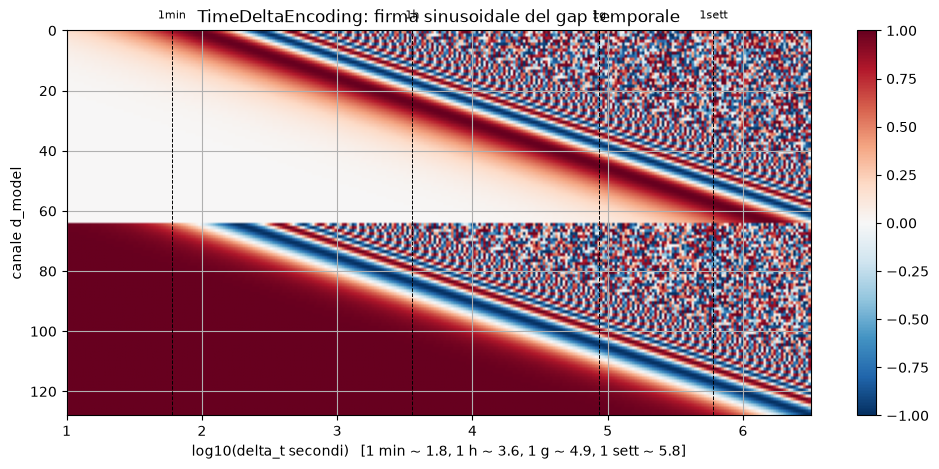

In [13]:
from src.models.hier_transformer.sequence_encoder import TimeDeltaEncoding

tde = TimeDeltaEncoding(d_model=128)
delta_sweep = torch.logspace(1, 6.5, 300)  # da 10 s a ~1 mese
with torch.no_grad():
    pe = tde(delta_sweep.unsqueeze(0)).squeeze(0)  # (300, 128)

plt.figure(figsize=(12, 5))
plt.imshow(pe.T.numpy(), aspect="auto", cmap="RdBu_r",
           extent=[1, 6.5, 128, 0])
plt.colorbar()
plt.xlabel("log10(delta_t secondi)   [1 min ~ 1.8, 1 h ~ 3.6, 1 g ~ 4.9, 1 sett ~ 5.8]")
plt.ylabel("canale d_model")
plt.title("TimeDeltaEncoding: firma sinusoidale del gap temporale")
for name, sec in [("1min", 60), ("1h", 3600), ("1g", 86400), ("1sett", 604800)]:
    plt.axvline(np.log10(sec), color="k", ls="--", lw=0.7)
    plt.text(np.log10(sec), -4, name, ha="center", fontsize=8)
plt.show()